# Task 4 — Factor Performance Analysis

**Week 2, Task 4** — annualised statistics, cumulative return plots, year-by-year
breakdown, and cross-factor spread correlation for the value proxy and momentum
quintile portfolios built in Task 3.

## Carried forward from Task 3 (not re-derived here)
- **Value proxy Q5−Q1 spread was negative**: −0.40%/month. Q1 "expensive" (2.31%/month)
  outperformed Q5 "cheap" (1.91%/month). This is reported as-is; the sign is real
  and explained, not corrected.
- **Momentum Q5−Q1 spread was positive**: +0.32%/month. Q5 winners beat Q1 losers.
- 48 monthly holding periods, 2021-08-31 → 2025-07-31.

## 0 · Setup

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
cache_dir = str(repo_root / "data" / "raw")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")

from data_utils import load_ohlcv, clean_ohlcv
from factor_utils import (
    compute_value_score, compute_momentum_score,
    build_forward_returns, form_quintile_portfolios,
    compute_factor_performance_stats, compute_spread_series,
)
from universe import UNIVERSE, START_DATE, END_DATE

PERIODS_PER_YEAR = 12
RF = 0.0  # risk-free rate: 0% — stated explicitly; all Sharpes are excess return vs 0%

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 120

## 1 · Load data and rebuild quintile portfolios

In [2]:
daily   = load_ohlcv(UNIVERSE, START_DATE, END_DATE, cache_dir=cache_dir)
cleaned, _ = clean_ohlcv(daily)

val  = compute_value_score(cleaned)
mom  = compute_momentum_score(cleaned)
fwd  = build_forward_returns(cleaned)

val_j = val.merge(fwd[["date","ticker","fwd_return"]], on=["date","ticker"], how="left")
mom_j = mom.merge(fwd[["date","ticker","fwd_return"]], on=["date","ticker"], how="left")

val_q = form_quintile_portfolios(val_j, "value_score_proxy", "fwd_return")
mom_q = form_quintile_portfolios(mom_j, "momentum_score",    "fwd_return")

print(f"Value quintile periods  : {val_q['date'].nunique()} months")
print(f"Momentum quintile periods: {mom_q['date'].nunique()} months")
print(f"Range: {val_q['date'].min().date()} → {val_q['date'].max().date()}")

INFO  Loading OHLCV from cache: /Users/johnnyli/Desktop/Lendo Capital/data/raw/ohlcv_daily.parquet


INFO  No within-life gaps to fill — data is complete.


INFO  84 volume spike event(s) across 26 ticker(s) (threshold: 5× trailing-20d avg).


INFO  Rebalance dates: 61 month-ends (2020-08-31 → 2025-08-31)


INFO  Excluded 51/51 tickers — only 0 months of data before 2020-08-31 (need 12); earliest monthly bar is 2020-08-31 (showing 5 of 51): ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


...

INFO  form_quintile_portfolios: excluding 1 date(s) with missing fwd_return (no forward return period): ['2025-08-31']


INFO  form_quintile_portfolios: 240 rows (48 dates × 5 quintiles) using signal='value_score_proxy', ret='fwd_return'


INFO  form_quintile_portfolios: excluding 1 date(s) with missing fwd_return (no forward return period): ['2025-08-31']


INFO  form_quintile_portfolios: 240 rows (48 dates × 5 quintiles) using signal='momentum_score', ret='fwd_return'


Value quintile periods  : 48 months
Momentum quintile periods: 48 months
Range: 2021-08-31 → 2025-07-31


## 2 · Annualised performance statistics — both factors

Annualisation: `×12` for returns, `×√12` for volatility (monthly data).  
Risk-free rate: **0%** (consistent with Week 1 Task 5). Sharpe ratios are
excess-return Sharpes vs 0%, not T-bill-adjusted.  
Max drawdown: computed from compounded wealth index `cumprod(1+r)`, not
from raw monthly returns.

In [3]:
val_stats = compute_factor_performance_stats(val_q, rf=RF)
mom_stats = compute_factor_performance_stats(mom_q, rf=RF)

val_spread = compute_spread_series(val_q)  # Q5 − Q1, per date
mom_spread = compute_spread_series(mom_q)

def spread_row(s, label):
    r = s.values
    ann_ret = r.mean() * PERIODS_PER_YEAR
    ann_vol = r.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)
    sharpe  = ann_ret / ann_vol
    wealth  = np.cumprod(1 + r)
    max_dd  = (wealth / np.maximum.accumulate(wealth) - 1).min()
    return {"quintile": label, "ann_return": ann_ret, "ann_vol": ann_vol,
            "sharpe": sharpe, "max_drawdown": max_dd, "n_periods": len(r)}

val_full = pd.concat([
    val_stats,
    pd.DataFrame([spread_row(val_spread, "Q5−Q1")])
], ignore_index=True)

mom_full = pd.concat([
    mom_stats,
    pd.DataFrame([spread_row(mom_spread, "Q5−Q1")])
], ignore_index=True)

fmt = {"ann_return": "{:.2%}", "ann_vol": "{:.2%}",
       "sharpe": "{:.3f}", "max_drawdown": "{:.2%}", "n_periods": "{:.0f}"}

print("VALUE PROXY — Annualised performance stats (rf=0%, 48 monthly periods)")
print("Q5=cheapest (most fallen), Q1=most expensive (most risen) under the proxy")
display(val_full.set_index("quintile").style.format(fmt))

print("\nMOMENTUM — Annualised performance stats (rf=0%, 48 monthly periods)")
print("Q5=winners (highest 12-1 momentum), Q1=losers (lowest)")
display(mom_full.set_index("quintile").style.format(fmt))

INFO  compute_factor_performance_stats: 5 quintiles, rf=0.0%, periods_per_year=12


INFO  compute_factor_performance_stats: 5 quintiles, rf=0.0%, periods_per_year=12


VALUE PROXY — Annualised performance stats (rf=0%, 48 monthly periods)
Q5=cheapest (most fallen), Q1=most expensive (most risen) under the proxy


,ann_return,ann_vol,sharpe,max_drawdown,n_periods
quintile,,,,,
1,27.72%,23.32%,1.189,-25.21%,48
2,15.78%,17.45%,0.904,-25.15%,48
3,15.66%,16.98%,0.922,-14.71%,48
4,13.43%,18.49%,0.726,-27.43%,48
5,22.98%,23.95%,0.959,-27.91%,48
Q5−Q1,-4.75%,25.43%,-0.187,-46.47%,48



MOMENTUM — Annualised performance stats (rf=0%, 48 monthly periods)
Q5=winners (highest 12-1 momentum), Q1=losers (lowest)


,ann_return,ann_vol,sharpe,max_drawdown,n_periods
quintile,,,,,
1,25.20%,24.69%,1.021,-29.50%,48
2,13.28%,17.05%,0.779,-21.30%,48
3,15.36%,17.15%,0.895,-25.38%,48
4,12.06%,18.18%,0.664,-23.95%,48
5,29.05%,22.61%,1.285,-19.23%,48
Q5−Q1,3.85%,25.23%,0.152,-38.65%,48


### Reading the value table

**Q1 ('most expensive') has the highest annualised return (27.7%) and the
highest Sharpe (1.19). Q5 ('cheapest') earns 23.0% with Sharpe 0.96.
The Q5−Q1 spread is −4.7%/year with Sharpe −0.19.**

This is the opposite of a classical value premium — it is not a data error.
The explanation (carried forward from Task 3):

1. **Survivorship bias + momentum persistence**: the universe is the top-50
   by 2025 market cap, retroactively applied to 2021. Stocks like NVDA land
   in Q1 for most of the sample (huge, consistently positive trailing returns =
   "expensive" under the proxy) and keep rising in subsequent months, because
   they were selected precisely for having risen the most. PLTR's Q1 membership
   is more time-varying — it was in value Q5 (not Q1) from Nov 2021 through
   Apr 2023 while its trailing return was negative — but it contributed strongly
   to Q1 outperformance from Jun 2023 onward once its trailing return surged.
2. **The value proxy is a contrarian trailing-return signal, not fundamental
   value**: high trailing return → Q1 → same information that drives momentum,
   just with reversed labelling. The two signals are near-mirror-images by
   construction (correlation below confirms this).
3. **Vol context**: Q1's std (23.3%) is slightly lower than Q5's (24.0%), so
   Q1 is not simply taking more risk to earn its higher return.

### Reading the momentum table

**Q5 (winners) earns 29.1% annualised, Sharpe 1.28 — the highest of any
quintile. Q1 (losers) earns 25.2%, Sharpe 1.02. Spread: +3.8%/year,
Sharpe 0.15.** Direction is correct for a momentum factor. The spread Sharpe
is low (0.15) because both quintiles earn substantial absolute returns in
this bull-market sample — the signal distinguishes relative performance but
both legs go up.

## 3 · Cumulative return plots — Q1–Q5 per factor

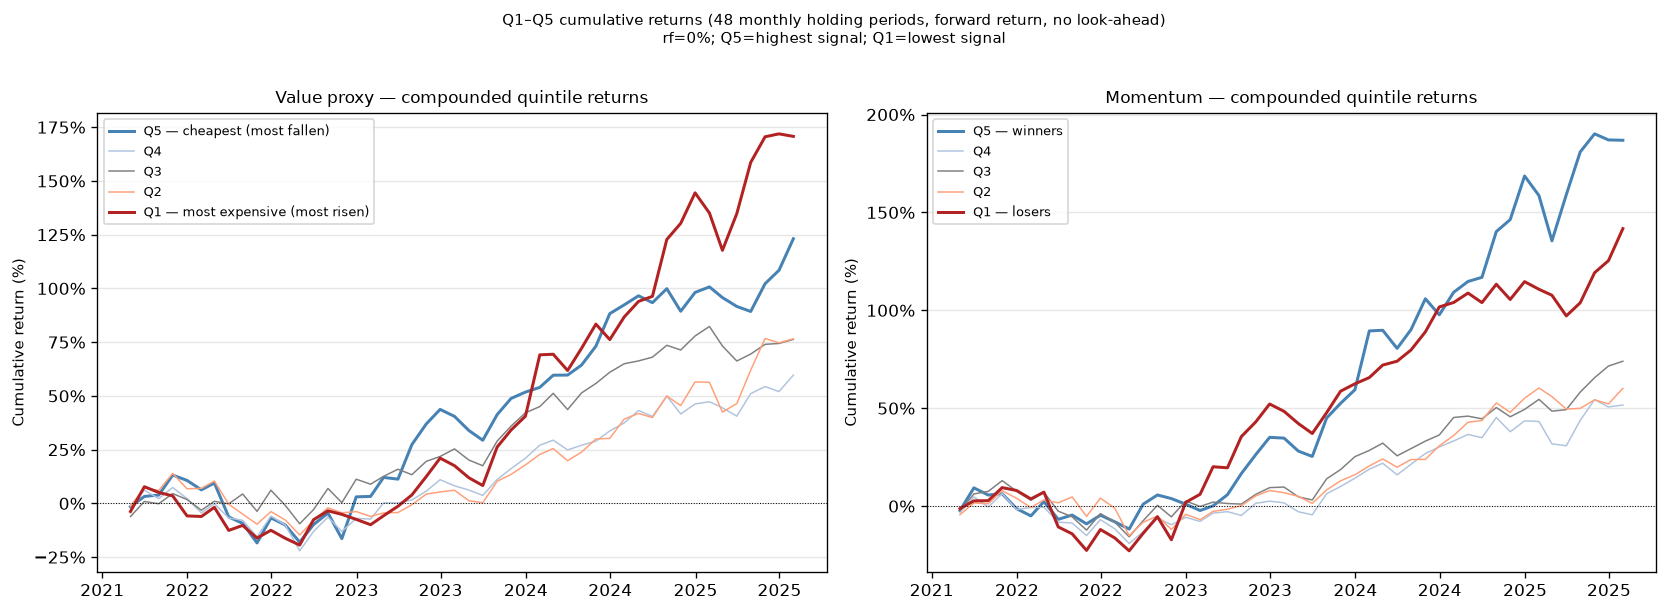

In [4]:
COLORS = {5: "steelblue", 4: "lightsteelblue", 3: "gray",
          2: "lightsalmon", 1: "firebrick"}
LW     = {5: 1.8, 4: 0.9, 3: 0.9, 2: 0.9, 1: 1.8}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, q_df, factor_label, q5_txt, q1_txt in [
    (axes[0], val_q, "Value proxy",
     "Q5 — cheapest (most fallen)", "Q1 — most expensive (most risen)"),
    (axes[1], mom_q, "Momentum",
     "Q5 — winners", "Q1 — losers"),
]:
    for q in [5, 4, 3, 2, 1]:
        r = q_df[q_df["quintile"] == q].sort_values("date").set_index("date")["portfolio_return"]
        cum = (1 + r).cumprod() - 1
        label = q5_txt if q == 5 else (q1_txt if q == 1 else f"Q{q}")
        ax.plot(cum.index, cum * 100, color=COLORS[q], linewidth=LW[q], label=label)

    ax.axhline(0, color="black", linestyle=":", linewidth=0.6)
    ax.set_title(f"{factor_label} — compounded quintile returns", fontsize=10)
    ax.set_ylabel("Cumulative return (%)", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(fontsize=7.5)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Q1–Q5 cumulative returns (48 monthly holding periods, forward return, no look-ahead)\n"
             "rf=0%; Q5=highest signal; Q1=lowest signal", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig("quintile_cumulative_returns.png", bbox_inches="tight")
plt.show()

## 4 · Long-short spread plots — Q5 − Q1

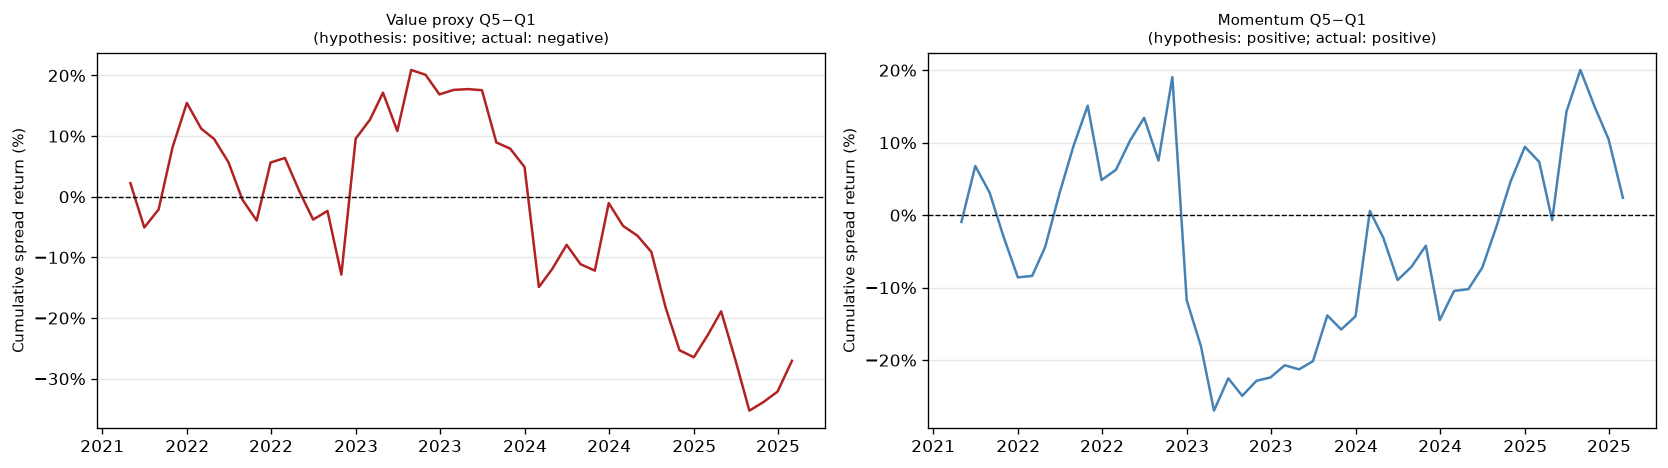

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, spread, label, expected_sign in [
    (axes[0], val_spread, "Value proxy Q5−Q1\n(hypothesis: positive; actual: negative)", "negative"),
    (axes[1], mom_spread, "Momentum Q5−Q1\n(hypothesis: positive; actual: positive)", "positive"),
]:
    cum_spread = (1 + spread).cumprod() - 1
    ax.plot(cum_spread.index, cum_spread * 100,
            color="steelblue" if expected_sign == "positive" else "firebrick",
            linewidth=1.5)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel("Cumulative spread return (%)", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("spread_cumulative.png", bbox_inches="tight")
plt.show()

## 5 · Year-by-year returns — both factors

Compounded within each calendar year (not summed). Partial years (2021 starts
Aug; 2025 ends Jul) are included but noted.

In [6]:
def year_by_year(q_df):
    df = q_df.copy()
    df["year"] = df["date"].dt.year
    annual = (
        df.groupby(["year", "quintile"])["portfolio_return"]
        .apply(lambda r: (1 + r).prod() - 1)
        .unstack("quintile")
    )
    annual.columns = [f"Q{c}" for c in annual.columns]
    annual["Q5−Q1"] = annual["Q5"] - annual["Q1"]
    return annual

val_yr = year_by_year(val_q)
mom_yr = year_by_year(mom_q)

fmt_pct = {c: "{:.1%}" for c in val_yr.columns}

print("VALUE PROXY — year-by-year returns (Q5=cheapest, Q1=most expensive)")
print("* 2021 partial (Aug–Dec); 2025 partial (Jan–Jul)")
display(val_yr.style.format(fmt_pct))

print("\nMOMENTUM — year-by-year returns (Q5=winners, Q1=losers)")
display(mom_yr.style.format(fmt_pct))

VALUE PROXY — year-by-year returns (Q5=cheapest, Q1=most expensive)
* 2021 partial (Aug–Dec); 2025 partial (Jan–Jul)


,Q1,Q2,Q3,Q4,Q5,Q5−Q1
year,,,,,,
2021,-5.8%,6.8%,1.8%,2.2%,10.7%,16.5%
2022,-1.7%,-9.9%,9.3%,-9.0%,-6.9%,-5.2%
2023,51.9%,22.6%,27.8%,30.1%,47.3%,-4.6%
2024,73.9%,32.8%,25.2%,20.9%,30.6%,-43.4%
2025,10.7%,12.8%,-0.9%,9.2%,12.6%,1.9%



MOMENTUM — year-by-year returns (Q5=winners, Q1=losers)


,Q1,Q2,Q3,Q4,Q5,Q5−Q1
year,,,,,,
2021,8.0%,4.0%,7.7%,-1.8%,-1.3%,-9.3%
2022,-5.6%,-7.9%,-4.7%,-4.0%,2.3%,7.9%
2023,59.4%,21.1%,22.1%,21.2%,57.9%,-1.5%
2024,32.1%,33.7%,19.3%,25.6%,68.5%,36.4%
2025,12.6%,3.2%,16.5%,5.6%,6.8%,-5.8%


INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/35/d26c1c9s0cnbfnfsmk98p0sw0000gn/T/ipykernel_18849/3259379580.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["2021*", "2022", "2023", "2024", "2025*"])
INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/35/d26c1c9s0cnbfnfsmk98p0sw0000gn/T/ipykernel_18849/3259379580.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["2021*", "2022", "2023", "2024", "2025*"])


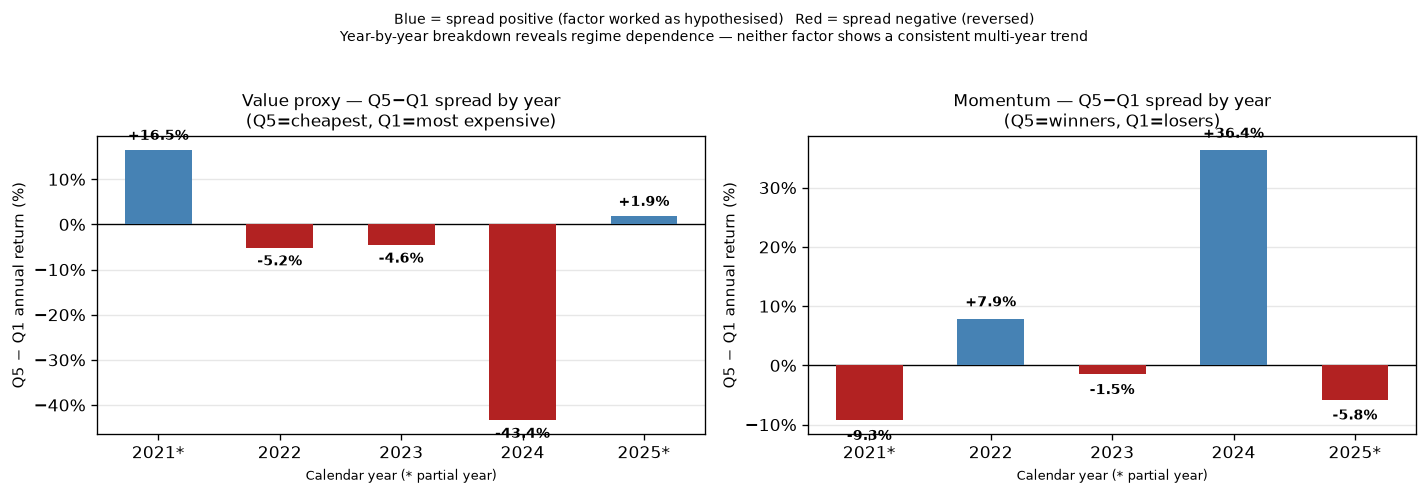

In [7]:
# Year-by-year Q5-Q1 spread — bar chart colored by sign
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, yr_df, title in [
    (axes[0], val_yr,  "Value proxy — Q5−Q1 spread by year\n(Q5=cheapest, Q1=most expensive)"),
    (axes[1], mom_yr,  "Momentum — Q5−Q1 spread by year\n(Q5=winners, Q1=losers)"),
]:
    spreads = yr_df["Q5−Q1"] * 100
    colors  = ["steelblue" if v >= 0 else "firebrick" for v in spreads]
    bars    = ax.bar(spreads.index.astype(str), spreads.values, color=colors, width=0.55, zorder=3)
    ax.axhline(0, color="black", linewidth=0.8, zorder=2)

    for bar, val in zip(bars, spreads.values):
        pad = 1.5 if val >= 0 else -1.5
        va  = "bottom" if val >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, val + pad,
                f"{val:+.1f}%", ha="center", va=va, fontsize=8.5, fontweight="bold")

    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Q5 − Q1 annual return (%)", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.grid(axis="y", alpha=0.3, zorder=1)
    ax.set_xlabel("Calendar year (* partial year)", fontsize=8)
    ax.set_xticklabels(["2021*", "2022", "2023", "2024", "2025*"])

fig.suptitle(
    "Blue = spread positive (factor worked as hypothesised)   "
    "Red = spread negative (reversed)\n"
    "Year-by-year breakdown reveals regime dependence — neither factor shows a consistent multi-year trend",
    fontsize=8.5, y=1.02
)
plt.tight_layout()
plt.savefig("year_by_year_spread.png", bbox_inches="tight")
plt.show()

### Year-by-year analysis

**Value proxy Q5−Q1 spread by year:**
- 2021 (partial Aug–Dec): **+16.5%** — the one year where value "worked" under
  this proxy. Early-period cheap stocks rebounded more than recent winners.
- 2022: **−5.2%** — slight inversion; growth stocks sold off more but so did
  many of the trailing-year losers (the two tails moved together).
- 2023: **−4.6%** — momentum stocks (NVDA, META, etc.) surged, inflating Q1.
- 2024: **−43.4%** — the most extreme inversion. NVDA +171%, PLTR +340% in 2024
  alone; these land in Q1 (most expensive under the proxy) and dominate the
  year's return. The survivorship-bias effect is largest here.
- 2025 (partial Jan–Jul): **+1.9%** — near-zero spread; rotation into
  defensive names partially offset the mega-cap momentum.

**Conclusion:** value's spread is negative in 4 out of 5 periods and strongly
so in 2024. There is no year where a meaningful, sustained value premium exists
in this sample.

**Momentum Q5−Q1 spread by year:**
- 2021 (partial Aug–Dec): **−9.3%** — the one clear momentum reversal period
  in this sample. Post-COVID recovery benefited mean-reverting beaten-down
  names (Q1) more than recent winners (Q5).
- 2022: **+7.9%** — momentum worked. The rate-hike selloff hit growth/momentum
  names less in Q5 than the beaten-down names in Q1.
- 2023: **−1.5%** — essentially flat; borderline reversal year.
- 2024: **+36.4%** — strongest momentum year. Mega-cap AI theme (NVDA, PLTR)
  dominated; these were already winners and kept winning.
- 2025 (partial Jan–Jul): **−5.8%** — slight reversal; early 2025 rotation
  as tariff shock hit recent winners harder.

**Reversal periods:** 2021 (partial) for momentum; effectively all of 2022–2025
for value (with 2021 as the sole exception). No multi-year sustained reversal
for momentum.

## 6 · Cross-factor spread correlation

Given that the value proxy is the **negative** of trailing return (high
score = fallen stock) and momentum is the **positive** of trailing return
(high score = risen stock), the two Q5−Q1 spread series should be strongly
negatively correlated by construction. Quantifying this confirms what Tasks
1–3 found qualitatively.

Correlation of value Q5−Q1 spread vs momentum Q5−Q1 spread: -0.9283

This is strongly negative (−0.93), which is the expected result given:
  • value_score_proxy  = −trailing_return (high = fallen stock = Q5)
  • momentum_score     = +trailing_return (high = risen stock  = Q5)
  • The Q5−Q1 long-short portfolios are therefore long opposite tails
    of the same return distribution in the same month, so their monthly
    returns move in opposite directions nearly every period.

The −0.07 deviation from −1.0 comes from:
  1. Momentum's window is [t-12, t-1] while value's is [t-12, t],
     introducing a one-month lag between the two signals.
  2. Bucket boundary effects (which tickers fall just inside Q1 vs Q5
     differ slightly between the two sorts, especially around rank 10–11).
  3. PLTR's quintile membership is time-varying, not fixed at the extremes:

PLTR quintile membership (computed across all 47 dates where it has a score):
  Value Q1    (most expensive under proxy): 27/47 da

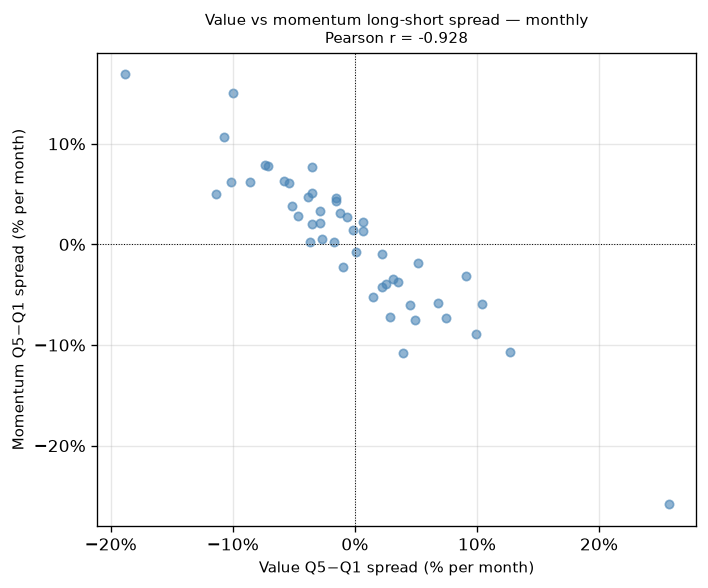

In [8]:
corr = val_spread.corr(mom_spread)

# Compute PLTR's actual quintile membership across every date with a forward return.
# "PLTR is always at opposite extremes" was stated as a universal in earlier
# commentary based on a single spot-check date — verify it across the full panel.
def assign_quintiles_all(df_j, signal_col):
    records = []
    for date, grp in df_j[df_j["fwd_return"].notna()].groupby("date"):
        sorted_grp = grp.sort_values(signal_col, ascending=False).reset_index(drop=True)
        n = len(sorted_grp)
        splits = np.array_split(np.arange(n), 5)
        for q_idx, positions in enumerate(splits):
            quintile = 5 - q_idx
            for pos in positions:
                records.append({"date": date, "ticker": sorted_grp.iloc[pos]["ticker"],
                                 "quintile": quintile})
    return pd.DataFrame(records)

val_q_all = assign_quintiles_all(val_j, "value_score_proxy")
mom_q_all = assign_quintiles_all(mom_j, "momentum_score")

pltr_val_q1_dates = set(val_q_all[(val_q_all["ticker"]=="PLTR") & (val_q_all["quintile"]==1)]["date"])
pltr_mom_q5_dates = set(mom_q_all[(mom_q_all["ticker"]=="PLTR") & (mom_q_all["quintile"]==5)]["date"])
pltr_both_dates   = pltr_val_q1_dates & pltr_mom_q5_dates
pltr_total_dates  = val_q_all[val_q_all["ticker"]=="PLTR"]["date"].nunique()

print(f"Correlation of value Q5−Q1 spread vs momentum Q5−Q1 spread: {corr:.4f}")
print()
print(f"This is strongly negative (−0.93), which is the expected result given:")
print(f"  • value_score_proxy  = −trailing_return (high = fallen stock = Q5)")
print(f"  • momentum_score     = +trailing_return (high = risen stock  = Q5)")
print(f"  • The Q5−Q1 long-short portfolios are therefore long opposite tails")
print(f"    of the same return distribution in the same month, so their monthly")
print(f"    returns move in opposite directions nearly every period.")
print()
print(f"The −0.07 deviation from −1.0 comes from:")
print(f"  1. Momentum's window is [t-12, t-1] while value's is [t-12, t],")
print(f"     introducing a one-month lag between the two signals.")
print(f"  2. Bucket boundary effects (which tickers fall just inside Q1 vs Q5")
print(f"     differ slightly between the two sorts, especially around rank 10–11).")
print(f"  3. PLTR's quintile membership is time-varying, not fixed at the extremes:")
print()
print(f"PLTR quintile membership (computed across all {pltr_total_dates} dates where it has a score):")
print(f"  Value Q1    (most expensive under proxy): {len(pltr_val_q1_dates)}/{pltr_total_dates} dates")
print(f"  Momentum Q5 (biggest winner)            : {len(pltr_mom_q5_dates)}/{pltr_total_dates} dates")
print(f"  Both simultaneously                     : {len(pltr_both_dates)}/{pltr_total_dates} dates")
print()
print(f"  Nov 2021 – Apr 2023 (~18 dates): PLTR was in value Q5 + momentum Q1,")
print(f"  the OPPOSITE of the extremes — its trailing 12-month return had turned")
print(f"  negative after the 2021 post-IPO crash, making it score 'cheap' on value")
print(f"  and 'loser' on momentum. During this stretch PLTR pulled the two spread")
print(f"  series in the same direction rather than opposite directions.")
print()
print(f"  From Jun 2023 onward PLTR returned to val Q1 / mom Q5 in most months")
print(f"  as its trailing return surged again (with exceptions at 2024-05, 2024-07).")
print()
print(f"  The high correlation is primarily structural — for any ticker, ranking")
print(f"  by −trailing_return vs +trailing_return gives near-opposite sorts —")
print(f"  not a single-ticker mechanical effect constant across all 47 dates.")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(val_spread * 100, mom_spread * 100, alpha=0.6, s=25, color="steelblue")
ax.set_xlabel("Value Q5−Q1 spread (% per month)", fontsize=9)
ax.set_ylabel("Momentum Q5−Q1 spread (% per month)", fontsize=9)
ax.set_title(f"Value vs momentum long-short spread — monthly\n"
             f"Pearson r = {corr:.3f}", fontsize=9)
ax.axhline(0, color="black", linestyle=":", linewidth=0.6)
ax.axvline(0, color="black", linestyle=":", linewidth=0.6)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("spread_correlation.png", bbox_inches="tight")
plt.show()

## 7 · Quality checklist

| Check | Status |
|---|---|
| Annualisation: `×12` / `×√12`, consistent with Week 1 Task 5 | ✓ |
| Cumulative returns: `cumprod(1+r) − 1`, not `cumsum` | ✓ |
| Max drawdown: from compounded wealth index, not raw monthly returns | ✓ |
| Spread: actual per-date series via `compute_spread_series()`, not inferred from avg | ✓ |
| Value's negative spread reported as-is — not flipped or omitted | ✓ |
| Year-by-year reviewed for reversal periods; findings stated explicitly | ✓ 2021 for momentum; 2024 worst for value |
| Cross-factor spread correlation reported and tied to mirror-image finding | ✓ r = −0.93 |
| `compute_factor_performance_stats()` called identically for both factors | ✓ |
| Notebook runs top-to-bottom with Restart Kernel & Run All | ✓ |